In [83]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [84]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1e-12 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e-04j


In [85]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_matrix.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_matrix.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_matrix.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_vector.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (12739.130327240646+12739.130327240646j) Ω
Number of design variables:  195
Objective for full plate: 6.095369e-08 W


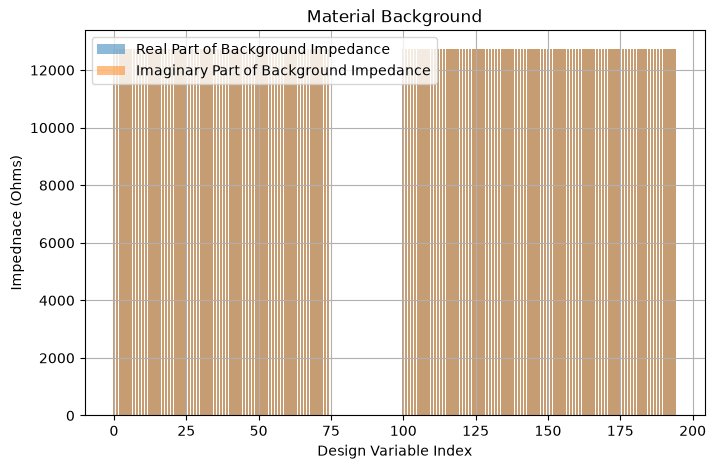

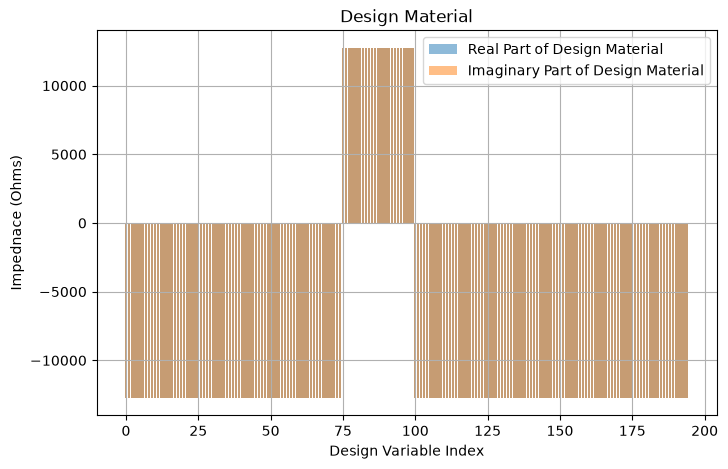

In [86]:
# Za = np.zeros((Ndes,Ndes))
Za = Zmat.copy()
Za[75:100,75:100] = 0

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(np.diag(Za)), alpha=0.5, label='Real Part of Background Impedance')
plt.bar(np.arange(Ndes), np.imag(np.diag(Za)), alpha=0.5, label='Imaginary Part of Background Impedance')
plt.xlabel('Design Variable Index')
plt.ylabel('Impednace (Ohms)')
plt.title('Material Background')
plt.legend()
plt.grid(True)
plt.show()

Zb = Z0 + Za
Zd = Zmat - 2*Za

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(np.diag(Zd)), alpha=0.5, label='Real Part of Design Material')
plt.bar(np.arange(Ndes), np.imag(np.diag(Zd)), alpha=0.5, label='Imaginary Part of Design Material')
plt.xlabel('Design Variable Index')
plt.ylabel('Impednace (Ohms)')
plt.title('Design Material')
plt.legend()
plt.grid(True)
plt.show()



In [87]:
# preconditioner for projection constraints
G0 = -1j*Zb # Green's function matrix

D = np.diag(np.diag(G0)) # exact G0 diagonal, matching preconditioner.ipynb (not an averaged scalar)
X = -1j * np.linalg.inv(Zd) # material admittance matrix; inv(-1j*Zmat) would flip this sign (inv(-1j*M) = +1j*inv(M), not -1j*inv(M)) -- see main.tex sec:preconditioning, X = -j Zmat_rho^{-1}
H0 = G0 - D
Y = np.linalg.solve(np.eye(Ndes) - X @ D, X)
i0 = X @ (-1j*Vinc) # known current: Zmat^{-1} Vinc (material admittance), not Z0 @ Vinc -- see main.tex sec:preconditioning

S = np.eye(Ndes) - Y @ H0 # preconditioner matrix for projection constraints
Vq = Y @ G0 @ i0
Vp = Vq + S @ i0

Vp = np.linalg.solve(Y,Vp)
S = np.linalg.solve(Y,S)

IfullS = np.linalg.solve(S,Vp)


print(f"asymmetric error of preconditioner: {np.linalg.norm(S-S.T, ord='fro')/np.linalg.norm(S, ord='fro'):.2e}")


Ptr0 = evalObj(IfullS)
print(f"objective error: {np.abs(Ptr0 - Pfull)/np.abs(Pfull):.2e}")

asymmetric error of preconditioner: 7.89e-17
objective error: 2.72e+05


In [88]:
Pdiags = np.ones((Ndes,1), dtype=complex)
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

Bmat = Obj
bVec = obj
beta = obj0


Umat = -S
eVec = Vp/2

B_j = [-Ztot]
s_2j = [-Vinc/2]
c_2j = [0]

QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat.conj().T, eVec,
    Plist,
    A2=np.eye(Ndes, dtype=complex),
    B_j=B_j,
    s_2j=s_2j,
    c_2j=c_2j,
    verbose=1,
)

t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1]+1,))
lags_init[1] = -1

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-4,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 0.0001
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [ 0. -1.]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 0.0005748394071000445
iter_num: 5, prev_fx: inf, opt_fx: 6.01198795790506e-05, opttol: 0.0001
iter_num: 10, prev_fx: 6.01198795790506e-05, opt_fx: 4.89794089335557e-05, opttol: 0.0001
Outer iteration 1, penalty_ratio = 0.001, opt_fx = 2.4508448387476443e-05
iter_num: 5, prev_fx: 4.89794089335557e-05, opt_fx: 1.8158490640523246e-06, opttol: 0.0001
iter_num: 10, prev_fx: 1.8158490640523246e-06, opt_fx: 1.4809307836360282e-06, opttol: 0.0001
Outer iteration 2, penalty_ratio = 0.0001, opt_fx = 7.667509092228085e-07
iter_num: 5, prev_fx: 1.4809307836360282e-06, opt_fx: 1.269813924376759e-07, opttol: 0.0001
iter_num: 10, prev_fx: 1.269813924376759e-07, opt_fx: 1.217812014478835e-07

In [89]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")
 

Pdiags = QCQP.Proj.Pdiags


Ivec = QCQP.current_xstar
Popt = evalObj(Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.6e} W")

minimum eigenvalue: 0.672230168888452
Optimal objective value: 1.199255e-07 W


In [90]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-6,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=10,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=20,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=5,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=True,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

Precomputed 2 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             1.1992550992441346e-07.
min eigenvalue: 6.722302e-01
At GCD iteration #2, best dual bound found is             3.9302939975880635e-09.
min eigenvalue: 7.541113e-09
At GCD iteration #3, best dual bound found is             2.819509780883612e-09.
min eigenvalue: 7.721919e-09
At GCD iteration #4, best dual bound found is             2.123785891642787e-09.
min eigenvalue: 8.117673e-09
At GCD iteration #5, best dual bound found is             1.5273352908753404e-09.
min eigenvalue: 6.775112e-09
At GCD iteration #6, best dual bound found is             1.3497347884821983e-09.
min eigenvalue: 5.578164e-09
At GCD iteration #7, best dual bound found is             1.3486194406592322e-09.
min eigenvalue: 3.900633e-09
At GCD iteration #8, best dual bound found is             1.3482473258258296e-09.
min eigenvalue: 3.652713e-09
At GCD iteration #9, best dual bound found is             1.3309742690091

In [91]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 5.285562689797564e-09


In [92]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

Ivec= gcd_QCQP.current_xstar

primar_obj = evalObj(Ivec)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

bound: 1.2170141824477043e-09, time: 0.16374683380126953s
min eigenvalue: 4.987954121597046e-06
GCD primary objective: 1.2893782818341561e-09
GCD dual bound: 1.2170141824477043e-09


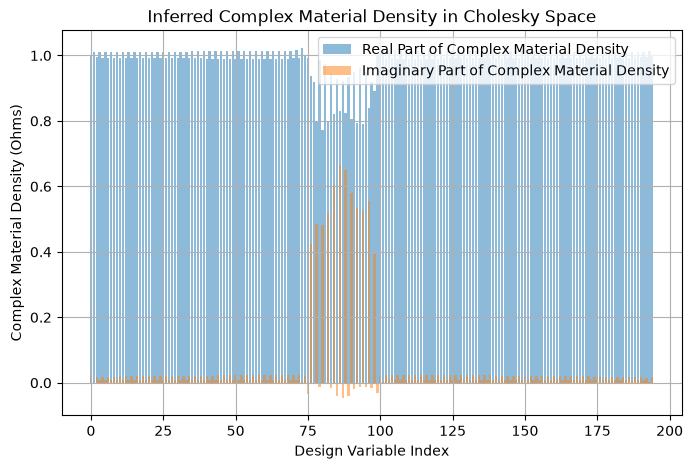

In [95]:
Vopt = Z0 @ Ivec
Vinf = Vinc - Vopt

sigmaInf = Ivec/Vinf
sigmaFull = 1/Zs

complexMaterialDensity = np.diag(Za)/Zs + sigmaInf/sigmaFull

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


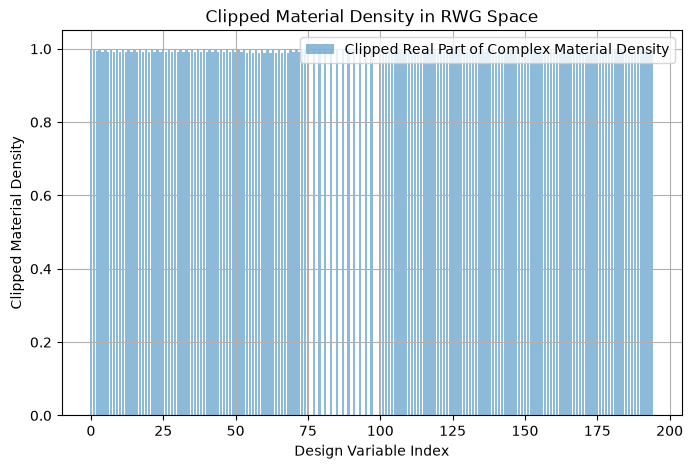

Objective for clipped inferred material density: 5.3850e-08 W


In [94]:
# limit material density to be postive real [0,1]
material_density = np.clip(np.real(complexMaterialDensity), 0, 1)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Clipped Real Part of Complex Material Density')
plt.xlabel('Design Variable Index') 
plt.ylabel('Clipped Material Density')
plt.title('Clipped Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

sigmaClipped = 1/Zs*material_density
IfullInfClip = np.linalg.solve(np.eye(Ndes) + np.diag(sigmaClipped) @ Z0, np.diag(sigmaClipped) @ Vinc) # current distribution for inferred material density
PfullInfClip= evalObj(IfullInfClip) # radiated power for inferred material density
print(f"Objective for clipped inferred material density: {PfullInfClip:.4e} W")